In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from scipy.stats import rankdata
from collections import Counter

In [83]:
class DAMEX(BaseEstimator, OutlierMixin):
    """
    Detecting Anomalies with Multivariate EXtremes (DAMEX) algorithm for anomaly detection.

    Parameters:
        k: int, default=None
            Number of extreme samples to consider. If None, set to sqrt(n).
        epsilon: float, default=0.01
            Tolerance parameter for cone assignment.
    """
    def __init__(self, k=None, epsilon=0.01):
        self.k = k
        self.epsilon = epsilon
        self.mass_ = {}
        self.training_data_ = None
        self.n_samples_ = 0
        self.d_ = 0

    def _marginal_standardization(self, X, reference_X=None):
        """
        Transforms data to Pareto scale (1 / (1 - F(x))).
        If reference_X is provided, ranks are computed relative to it.
        """
        X = np.asarray(X)
        n, d = X.shape

        if reference_X is None:
            # Fit, train: Rank transform using X
            ranks = np.apply_along_axis(rankdata, 0, X)
            V = 1.0 / (1.0 - ranks / (n + 1))
        else:
            # Predict, score: Rank test data relative to training data
            # Count how many training samples are less than each test sample
            V = np.zeros_like(X)
            ref = np.asarray(reference_X)
            for j in range(d):
                sorted_ref = np.sort(ref[:, j])
                ranks = np.searchsorted(sorted_ref, X[:, j], side='right') + 1
                V[:, j] = 1.0 / (1.0 - ranks / (self.n_samples_ + 1))
        
        return V

    def _assign_cones(self, V):
        """
        Assigns each vector in V to a cone alpha based on epsilon-thickening.
        Returns a list of tuples, where each tuple contains indices of active features.
        """
        R = np.max(V, axis=1, keepdims=True)
        R[R == 0] = 1e-10  # Avoid division by zero

        # v_j > epsilon * ||V||_infty
        active_indices = (V > self.epsilon * R)
        
        cones = []
        for row in active_indices:
            indices = tuple(np.where(row)[0])
            cones.append(indices)
        
        return cones, R.flatten()

    def fit(self, X, y=None):
        """
        Learn the sparse dependence structure (mass of sub-cones)
        """
        X = np.asarray(X)
        self.n_samples_, self.d_ = X.shape
        self.training_data_ = X

        # Default k = sqrt(n)
        if self.k is None:
            self.k = int(np.sqrt(self.n_samples_))

        # Marginal standardization
        V = self._marginal_standardization(X)

        # Thresholding: select extreme observations
        radial_threshold = self.n_samples_ / self.k
        R = np.max(V, axis=1)
        extreme_indices = (R > radial_threshold)

        V_extreme = V[extreme_indices]

        # Assign cones
        cones, _ = self._assign_cones(V_extreme)

        # Estimate mass for each cone
        counts = Counter(cones)
        self.mass_ = {alpha: count / self.k for alpha, count in counts.items()}

        return self

    def decision_function(self, X):
        """
        Compute anomaly scores. Lower scores = more anomalous.
        score: s_n(x) ~ Prob(Extreme in direction x)
        """
        check_is_fitted = self.mass_
        X = np.asarray(X)

        # Transform data
        V = self._marginal_standardization(X, reference_X=self.training_data_)

        # Assign cones
        cones, R = self._assign_cones(V)

        # Compute scores
        scores = np.zeros(X.shape[0])

        for i, (alpha, r) in enumerate(zip(cones, R)):
            # Get mass for cone alpha
            mass = self.mass_.get(alpha, 0)
            # Compute score s_n(x) = w_n(x) / ||V||_infty
            scores[i] = mass / r if r > 0 else 0

        return scores

In [84]:
def generate_synthetic_data(n_samples=1000, d=10, contamination=0.05):
    """
    Generates synthetic data:
    - Normal data: Heavy-tailed t-distribution, correlated.
    - Anomalies: Uniform in hypercube (breaking the dependence structure).
    """
    # 1. Generate "Normal" Data (Dependence Structure)
    # Using Multivariate t-distribution to simulate heavy tails
    df = 3 # Degrees of freedom (lower = heavier tails)
    mean = np.zeros(d)
    
    # Create a sparse dependence matrix (block diagonal-ish)
    cov = np.eye(d)
    # Introduce strong correlation between first 3 variables
    cov[0:3, 0:3] = 0.9
    np.fill_diagonal(cov, 1.0)
    
    # Generate multivariate normal
    x = np.random.multivariate_normal(mean, cov, n_samples)
    # Divide by chi-square to get t-distribution
    u = np.random.chisquare(df, n_samples) / df
    X_normal = x / np.sqrt(u)[:, None]
    
    # 2. Generate Anomalies (Uniform noise, breaking correlation)
    n_anomalies = int(n_samples * contamination)
    # Uniform anomalies in the range of the data
    limit = np.max(np.abs(X_normal))
    X_anom = np.random.uniform(-limit, limit, (n_anomalies, d))
    
    # Combine
    X = np.vstack([X_normal, X_anom])
    y = np.hstack([np.zeros(len(X_normal)), np.ones(len(X_anom))]) # 0=Normal, 1=Anomaly
    
    return X, y

In [85]:
# Configuration
N_TRAIN = 5000
N_TEST = 2000
DIM = 10
K = 150 # Number of extremes (paper suggests sqrt(n) or heuristic)
EPSILON = 0.01

In [86]:
print(f"Generating synthetic data (d={DIM})...")
X_train, y_train = generate_synthetic_data(N_TRAIN, DIM, contamination=0.0) # Clean training
X_test, y_test = generate_synthetic_data(N_TEST, DIM, contamination=0.05)   # Polluted test

Generating synthetic data (d=10)...


In [87]:
print("Training DAMEX...")
damex = DAMEX(k=K, epsilon=EPSILON)
damex.fit(X_train)

Training DAMEX...


,k,150
,epsilon,0.01


In [88]:
 print(f"Number of active sub-cones found: {len(damex.mass_)}")
# Print top 5 cones by mass
sorted_cones = sorted(damex.mass_.items(), key=lambda x: x[1], reverse=True)
print("Top 5 dominant cones (indices of features):")
for cone, mass in sorted_cones[:5]:
    print(f"  Features {cone}: Mass = {mass:.4f}")

Number of active sub-cones found: 202
Top 5 dominant cones (indices of features):
  Features (np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)): Mass = 3.7933
  Features (np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9)): Mass = 0.0400
  Features (np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9)): Mass = 0.0267
  Features (np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9)): Mass = 0.0267
  Features (np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(9)): Mass = 0.0267


In [89]:
print("Scoring test data...")
scores = damex.decision_function(X_test)

Scoring test data...


C:\Users\adoni\AppData\Local\Temp\ipykernel_24380\1786216919.py:39: RuntimeWarning: divide by zero encountered in divide
  V[:, j] = 1.0 / (1.0 - ranks / (self.n_samples_ + 1))


In [90]:
anomaly_scores = -scores

V_test = damex._marginal_standardization(X_test, reference_X=X_train)
R_test = np.max(V_test, axis=1)
threshold = X_train.shape[0] / K

extreme_mask = R_test > threshold
X_test_ext = X_test[extreme_mask]
y_test_ext = y_test[extreme_mask]
scores_ext = anomaly_scores[extreme_mask]

print(f"\nEvaluation on Extreme Region (n={np.sum(extreme_mask)} samples):")
    
if len(np.unique(y_test_ext)) < 2:
    print("Not enough diversity in extreme region for AUC calculation.")
else:
    auc_roc = roc_auc_score(y_test_ext, scores_ext)
    precision, recall, _ = precision_recall_curve(y_test_ext, scores_ext)
    auc_pr = auc(recall, precision)
    
    print(f"ROC AUC: {auc_roc:.4f}")
    print(f"PR AUC:  {auc_pr:.4f}")


Evaluation on Extreme Region (n=451 samples):
ROC AUC: 0.9219
PR AUC:  0.8214


C:\Users\adoni\AppData\Local\Temp\ipykernel_24380\1786216919.py:39: RuntimeWarning: divide by zero encountered in divide
  V[:, j] = 1.0 / (1.0 - ranks / (self.n_samples_ + 1))



Plot saved to 'damex_score_distribution.png'


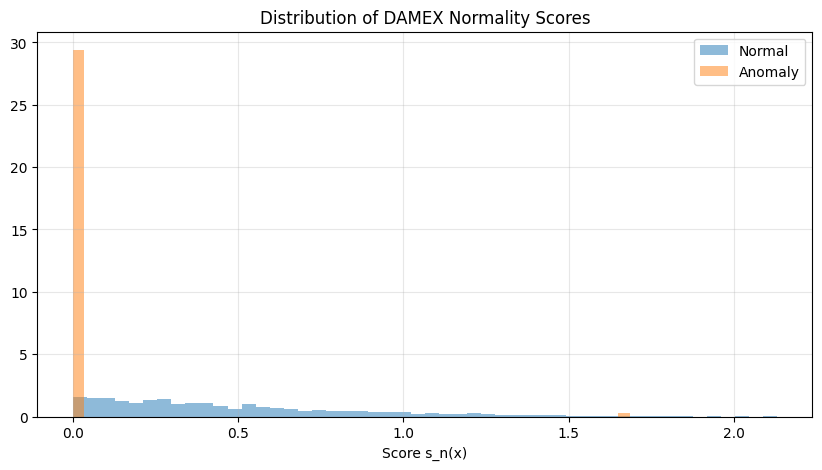

In [91]:
try:
    plt.figure(figsize=(10, 5))
    plt.hist(scores[y_test==0], bins=50, alpha=0.5, label='Normal', density=True)
    plt.hist(scores[y_test==1], bins=50, alpha=0.5, label='Anomaly', density=True)
    plt.title("Distribution of DAMEX Normality Scores")
    plt.xlabel("Score s_n(x)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("damex_score_distribution.png")
    print("\nPlot saved to 'damex_score_distribution.png'")
except Exception as e:
    print(f"Could not generate plot: {e}")